# London Crime Weather (2014 - 2016) Analysis
This analysis explores the relationship between crime rates and weather conditions.

## 1. Add Libraries
- ggplot2: Data Visualization Charts
- dplyr: Data Manipulation
- corrplot: Correlation Visualization

In [206]:
# List of Need Libaries
required_packages <- c(
  "ggplot2", "dplyr", "broom", "corrplot", "scales", "readr", "lubridate"
)

# Install
installed <- rownames(installed.packages())

# Check if Library is installed
for (pkg in required_packages) {
  if (!pkg %in% installed) install.packages(pkg)
}

# Add Libraies
library(ggplot2)
library(dplyr)
library(corrplot)
library(scales)
library(readr)
library(lubridate)

## 2. Load Data
Load merge csv file from github which contains data London Crime and Weather data from 2014 to 2016

In [207]:
# Load File from Github
raw_data <- read_csv(
 'https://raw.githubusercontent.com/bcroman/21006366_DA_Assessment/refs/heads/main/views/Crime_Weather_2014_2016.csv',
  show_col_types = FALSE
)

In [208]:
# Output Summary Data
summary(raw_data)
glimpse(raw_data)

      year          month       crime_month        major_category    
 Min.   :2014   Min.   : 1.00   Length:252         Length:252        
 1st Qu.:2014   1st Qu.: 3.75   Class :character   Class :character  
 Median :2015   Median : 6.50   Mode  :character   Mode  :character  
 Mean   :2015   Mean   : 6.50                                        
 3rd Qu.:2016   3rd Qu.: 9.25                                        
 Max.   :2016   Max.   :12.00                                        
  total_crimes      avg_temp        avg_dewp        avg_slp     
 Min.   :  925   Min.   :40.81   Min.   :35.19   Min.   : 9690  
 1st Qu.: 1889   1st Qu.:45.21   1st Qu.:39.36   1st Qu.:10000  
 Median : 5187   Median :52.89   Median :46.56   Median :10000  
 Mean   : 8444   Mean   :53.50   Mean   :45.49   Mean   : 9983  
 3rd Qu.:16409   3rd Qu.:61.65   3rd Qu.:51.52   3rd Qu.:10000  
 Max.   :26303   Max.   :67.73   Max.   :55.60   Max.   :10000  
   avg_visib          avg_wdsp        avg_mxpsd        

Rows: 252
Columns: 17
$ year           <dbl> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2…
$ month          <dbl> 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3…
$ crime_month    <chr> "01/01/2014", "01/01/2014", "01/01/2014", "01/01/2014",…
$ major_category <chr> "Robbery", "Violence Against the Person", "Criminal Dam…
$ total_crimes   <dbl> 2165, 12741, 4464, 4020, 930, 23285, 7910, 1878, 6767, …
$ avg_temp       <dbl> 44.59355, 44.59355, 44.59355, 44.59355, 44.59355, 44.59…
$ avg_dewp       <dbl> 40.44839, 40.44839, 40.44839, 40.44839, 40.44839, 40.44…
$ avg_slp        <dbl> 9999.9, 9999.9, 9999.9, 9999.9, 9999.9, 9999.9, 9999.9,…
$ avg_visib      <dbl> 5.974194, 5.974194, 5.974194, 5.974194, 5.974194, 5.974…
$ avg_wdsp       <dbl> 9.367742, 9.367742, 9.367742, 9.367742, 9.367742, 9.367…
$ avg_mxpsd      <dbl> 16.23226, 16.23226, 16.23226, 16.23226, 16.23226, 16.23…
$ avg_gust       <dbl> 466.0968, 466.0968, 466.0968, 466.0968, 466.0968, 466.0…
$ avg_max_temp   <

## 3. Clean Dataset
- Remove Columns that have values '999'

In [209]:
# Replace likely missing-value placeholders with NA
raw_data <- raw_data %>%
  mutate(
    crime_month = dmy(crime_month),
    avg_sndp = ifelse(avg_sndp == 999.9, NA, avg_sndp),
    avg_slp  = ifelse(avg_slp == 9999.9, NA, avg_slp)
  )

## 4. Monthly total crime + weather
Weather is repeated for each crime category in the same month, so we aggregate to one row per month

In [210]:
# Sort Monthly Total Values by one row is per month
monthly_data <- raw_data %>%
  group_by(year, month, crime_month) %>%
  summarise(
    total_crime   = sum(total_crimes, na.rm = TRUE),
    avg_temp      = first(avg_temp),
    avg_dewp      = first(avg_dewp),
    avg_slp       = first(avg_slp),
    avg_visib     = first(avg_visib),
    avg_wdsp      = first(avg_wdsp),
    avg_mxpsd     = first(avg_mxpsd),
    avg_gust      = first(avg_gust),
    avg_max_temp  = first(avg_max_temp),
    avg_min_temp  = first(avg_min_temp),
    avg_prcp      = first(avg_prcp),
    avg_sndp      = first(avg_sndp),
    fog_days      = first(fog_days),
    .groups = "drop"
  ) %>%
  arrange(crime_month) %>%
  mutate(
      month_factor = factor(
        month.abb[month],
        levels = month.abb
      )
    )

glimpse(monthly_data) # Display Results

Rows: 36
Columns: 17
$ year         <dbl> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month        <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6, …
$ crime_month  <date> 2014-01-01, 2014-02-01, 2014-03-01, 2014-04-01, 2014-05-…
$ total_crime  <dbl> 55515, 51222, 57669, 53467, 56327, 57039, 58564, 55641, 5…
$ avg_temp     <dbl> 44.59355, 45.41786, 48.12258, 52.87000, 56.64516, 62.9133…
$ avg_dewp     <dbl> 40.44839, 38.94643, 39.50000, 43.99333, 46.74839, 50.2900…
$ avg_slp      <dbl> NA, NA, NA, NA, NA, NA, 9709.984, NA, NA, NA, NA, NA, NA,…
$ avg_visib    <dbl> 5.974194, 6.542857, 37.709677, 5.813333, 38.387097, 106.0…
$ avg_wdsp     <dbl> 9.367742, 12.246429, 7.651613, 7.263333, 7.832258, 6.2900…
$ avg_mxpsd    <dbl> 16.23226, 20.12500, 13.95806, 12.49333, 13.13548, 11.5966…
$ avg_gust     <dbl> 466.0968, 308.4607, 716.6065, 804.8167, 591.4871, 674.400…
$ avg_max_temp <dbl> 50.07419, 51.11071, 57.52258, 61.07333, 64.39032, 71.9833…
$ avg_min_temp <dbl

In [211]:
# Create Dataset For Monthly Category
category_monthly <- raw_data %>%
  select(
    year, month, crime_month,
    major_category, total_crimes,
    avg_temp, avg_dewp, avg_visib, avg_wdsp,
    avg_mxpsd, avg_gust, avg_max_temp, avg_min_temp, avg_prcp, fog_days
  ) %>%
  arrange(crime_month, major_category)

glimpse(category_monthly) # Display Result

Rows: 252
Columns: 15
$ year           <dbl> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2…
$ month          <dbl> 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3…
$ crime_month    <date> 2014-01-01, 2014-01-01, 2014-01-01, 2014-01-01, 2014-0…
$ major_category <chr> "Burglary", "Criminal Damage", "Drugs", "Other Notifiab…
$ total_crimes   <dbl> 7910, 4464, 4020, 930, 2165, 23285, 12741, 6767, 4236, …
$ avg_temp       <dbl> 44.59355, 44.59355, 44.59355, 44.59355, 44.59355, 44.59…
$ avg_dewp       <dbl> 40.44839, 40.44839, 40.44839, 40.44839, 40.44839, 40.44…
$ avg_visib      <dbl> 5.974194, 5.974194, 5.974194, 5.974194, 5.974194, 5.974…
$ avg_wdsp       <dbl> 9.367742, 9.367742, 9.367742, 9.367742, 9.367742, 9.367…
$ avg_mxpsd      <dbl> 16.23226, 16.23226, 16.23226, 16.23226, 16.23226, 16.23…
$ avg_gust       <dbl> 466.0968, 466.0968, 466.0968, 466.0968, 466.0968, 466.0…
$ avg_max_temp   <dbl> 50.07419, 50.07419, 50.07419, 50.07419, 50.07419, 50.07…
$ avg_min_temp   <

## 5. Correlation Matics
Get Correlaion matrics for Total Crimes Vs Weather & Crime Type Vs Weather


In [212]:
# Select numberic values
corr_data <- monthly_data %>%
  select(
    total_crime,
    avg_temp, avg_dewp, avg_visib, avg_wdsp,
    avg_mxpsd, avg_gust, avg_max_temp, avg_min_temp,
    avg_prcp, fog_days
  )

# Get Correlatoion Values
corr_matrix <- cor(corr_data)

# Print Full Table
cat("Full correlation matrix:\n")
corr_matrix

# Get and Print The highest correlation over Total Crimes
cat("\nCorrelation of total_crimes with weather variables:\n")
crime_corr <- round(corr_matrix["total_crime", ], 3)
print(sort(crime_corr, decreasing = TRUE))

Full correlation matrix:


,total_crime,avg_temp,avg_dewp,avg_visib,avg_wdsp,avg_mxpsd,avg_gust,avg_max_temp,avg_min_temp,avg_prcp,fog_days
total_crime,1.00000000,0.34901380,0.4125559,-0.13848169,-0.2011894,-0.2669362,0.07604075,0.31261908,0.37812797,0.56791422,0.1199760
avg_temp,0.34901380,1.00000000,0.9423154,0.33637949,-0.3032029,-0.3507794,0.20613424,0.99166571,0.99193787,0.08543204,-0.3758681
avg_dewp,0.41255591,0.94231541,1.0000000,0.14328227,-0.3404702,-0.3963448,0.20820604,0.90171331,0.96743487,0.13883575,-0.2143987
avg_visib,-0.13848169,0.33637949,0.1432823,1.00000000,-0.1486099,-0.1002398,0.08977585,0.39649211,0.27617120,-0.28631496,-0.2518673
avg_wdsp,-0.20118935,-0.30320289,-0.3404702,-0.14860987,1.0000000,0.9863245,-0.85570318,-0.33380449,-0.27802598,-0.27338257,-0.3694457
avg_mxpsd,-0.26693620,-0.35077943,-0.3963448,-0.10023984,0.9863245,1.0000000,-0.85049326,-0.37286447,-0.33014889,-0.29150064,-0.3151945
avg_gust,0.07604075,0.20613424,0.2082060,0.08977585,-0.8557032,-0.8504933,1.00000000,0.25653492,0.17425207,0.08975584,0.2624866
avg_max_temp,0.31261908,0.99166571,0.9017133,0.39649211,-0.3338045,-0.3728645,0.25653492,1.00000000,0.96917474,0.07101813,-0.3763984
avg_min_temp,0.37812797,0.99193787,0.9674349,0.27617120,-0.2780260,-0.3301489,0.17425207,0.96917474,1.00000000,0.09676376,-0.3574119
avg_prcp,0.56791422,0.08543204,0.1388357,-0.28631496,-0.2733826,-0.2915006,0.08975584,0.07101813,0.09676376,1.00000000,0.4336523



Correlation of total_crimes with weather variables:
 total_crime     avg_prcp     avg_dewp avg_min_temp     avg_temp avg_max_temp 
       1.000        0.568        0.413        0.378        0.349        0.313 
    fog_days     avg_gust    avg_visib     avg_wdsp    avg_mxpsd 
       0.120        0.076       -0.138       -0.201       -0.267 


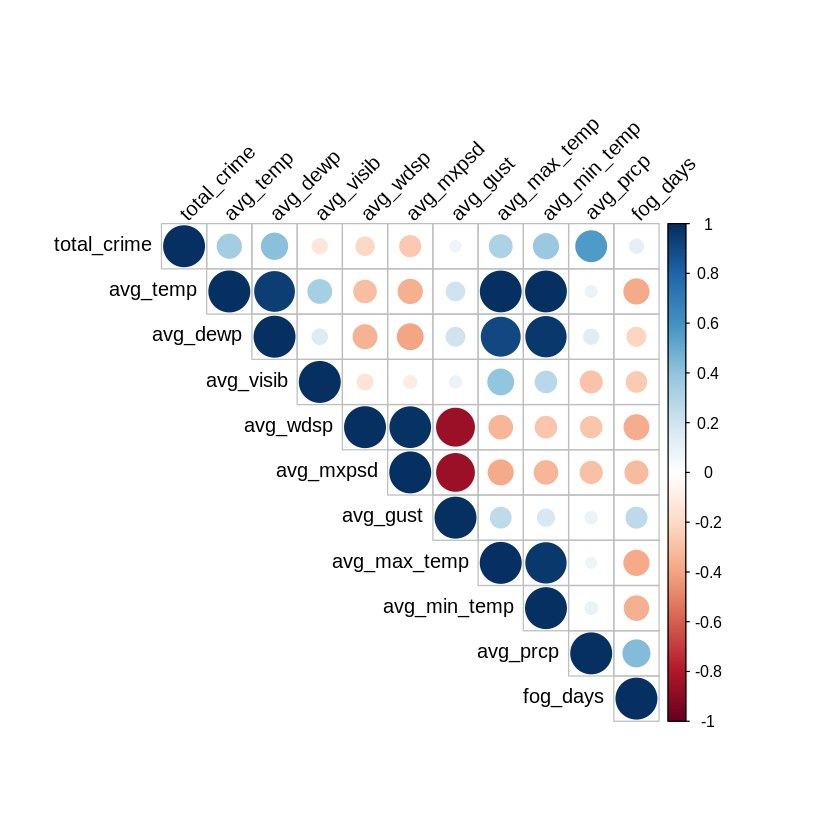

In [213]:
# Corralation Matrix Chart
corrplot(
  corr_matrix,
  type = "upper",
  tl.col = "black",
  tl.srt = 45,
)

In [214]:
# Get Choice Weather Data
crime_weather_type <- raw_data %>%
  group_by(crime_month, major_category) %>%
  summarise(
    total = sum(total_crimes, na.rm = TRUE),
    avg_temp = first(avg_temp),
    avg_prcp = first(avg_prcp),
    fog_days = first(fog_days),
    avg_wdsp = first(avg_wdsp),
    .groups = "drop"
  )

# Get Correlation Matric For Crime Type
cor_by_type <- crime_weather_type %>%
  group_by(major_category) %>%
  summarise(
    cor_temp = cor(total, avg_temp, use = "complete.obs"),
    cor_prcp = cor(total, avg_prcp, use = "complete.obs"),
    cor_fog  = cor(total, fog_days, use = "complete.obs"),
    cor_wdsp = cor(total, avg_wdsp, use = "complete.obs"),
  )

# Display Result
cat("\nCorrelation by Crime Type:\n")
print(cor_by_type)



Correlation by Crime Type:
# A tibble: 7 × 5
  major_category              cor_temp cor_prcp  cor_fog cor_wdsp
  <chr>                          <dbl>    <dbl>    <dbl>    <dbl>
1 Burglary                    -0.623     -0.285  0.400     0.403 
2 Criminal Damage              0.478      0.405 -0.0939   -0.199 
3 Drugs                        0.00306   -0.345 -0.00204   0.0887
4 Other Notifiable Offences    0.478      0.563 -0.100    -0.347 
5 Robbery                     -0.0764     0.447  0.585    -0.0775
6 Theft and Handling           0.323      0.589  0.282    -0.253 
7 Violence Against the Person  0.399      0.502 -0.109    -0.219 


## 6. Charts
Display Different Charts

### 6.1 Total Crime Vs Weather Data

Total Crimes vs Precipitation:  0.5679142

`geom_smooth()` using formula = 'y ~ x'


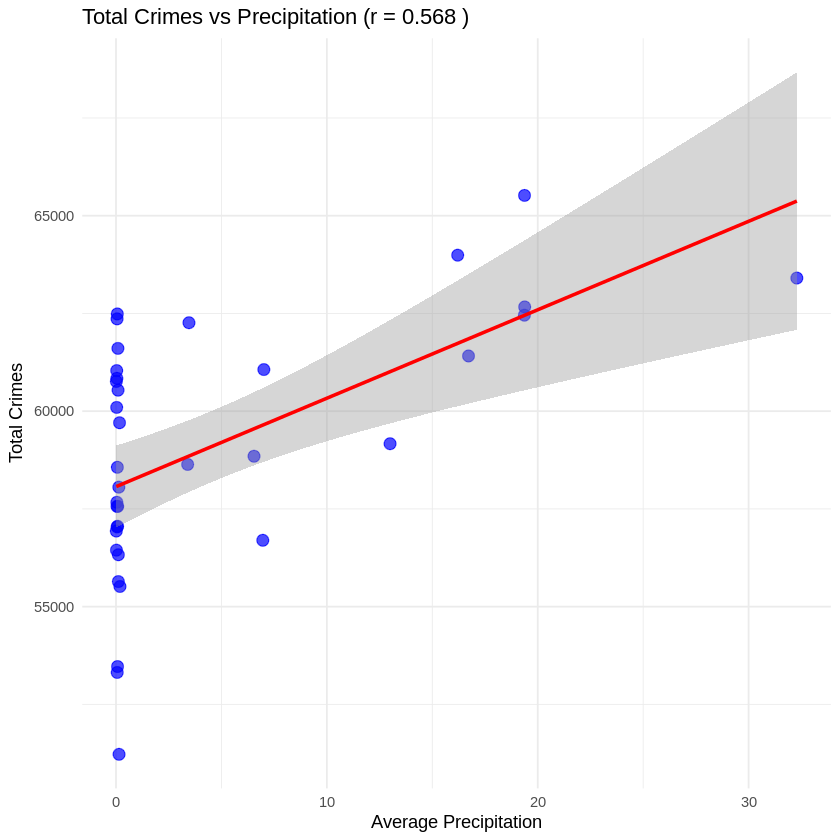

In [215]:
# Get Correlation Matrix Value
cor_value <- cor(monthly_data$total_crime, monthly_data$avg_prcp)
cat("Total Crimes vs Precipitation: ", cor_value)

# Display Chart
ggplot(monthly_data, aes(x = avg_prcp, y = total_crime)) +
  geom_point(size = 3, alpha = 0.7, color = "blue") +
  geom_smooth(method = "lm", se = TRUE, color = "red") +
  labs(
    title = paste("Total Crimes vs Precipitation (r =", round(cor_value, 3), ")"),
    x = "Average Precipitation",
    y = "Total Crimes"
  ) +
  theme_minimal()

Total Crimes vs Temperature:  0.3490138

`geom_smooth()` using formula = 'y ~ x'


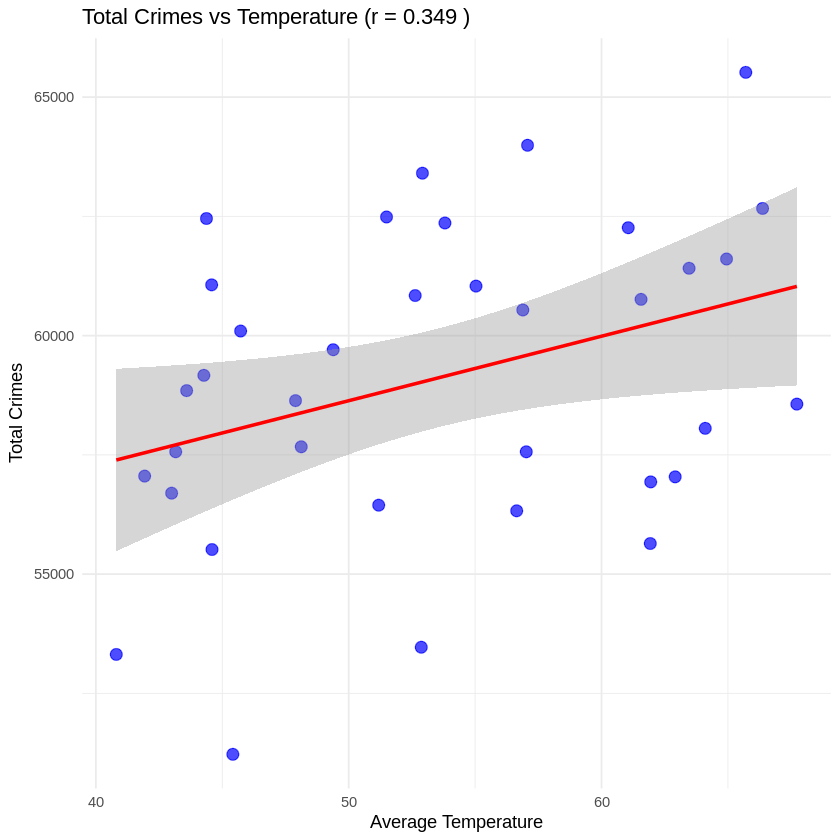

In [216]:
# Get Correlation Matrix Value
cor_value <- cor(monthly_data$total_crime, monthly_data$avg_temp)
cat("Total Crimes vs Temperature: ", cor_value)

# Display Chart
ggplot(monthly_data, aes(x = avg_temp, y = total_crime)) +
  geom_point(size = 3, alpha = 0.7, color = "blue") +
  geom_smooth(method = "lm", se = TRUE, color = "red") +
  labs(
    title = paste("Total Crimes vs Temperature (r =", round(cor_value, 3), ")"),
    x = "Average Temperature",
    y = "Total Crimes"
  ) +
  theme_minimal()

### 6.2 Total Crime Vs Timeline

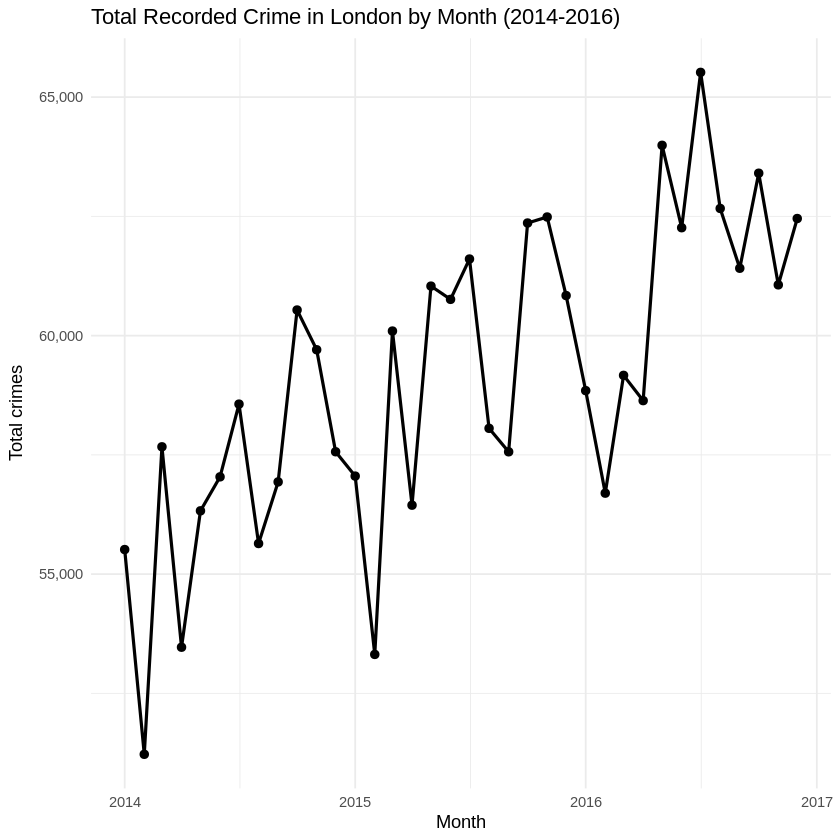

In [217]:
# Display Chart
ggplot(monthly_data, aes(x = crime_month, y = total_crime, group = 1)) +
  geom_line(linewidth = 0.9) +
  geom_point(size = 2) +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Total Recorded Crime in London by Month (2014-2016)",
    x = "Month",
    y = "Total crimes"
  ) +
  theme_minimal()

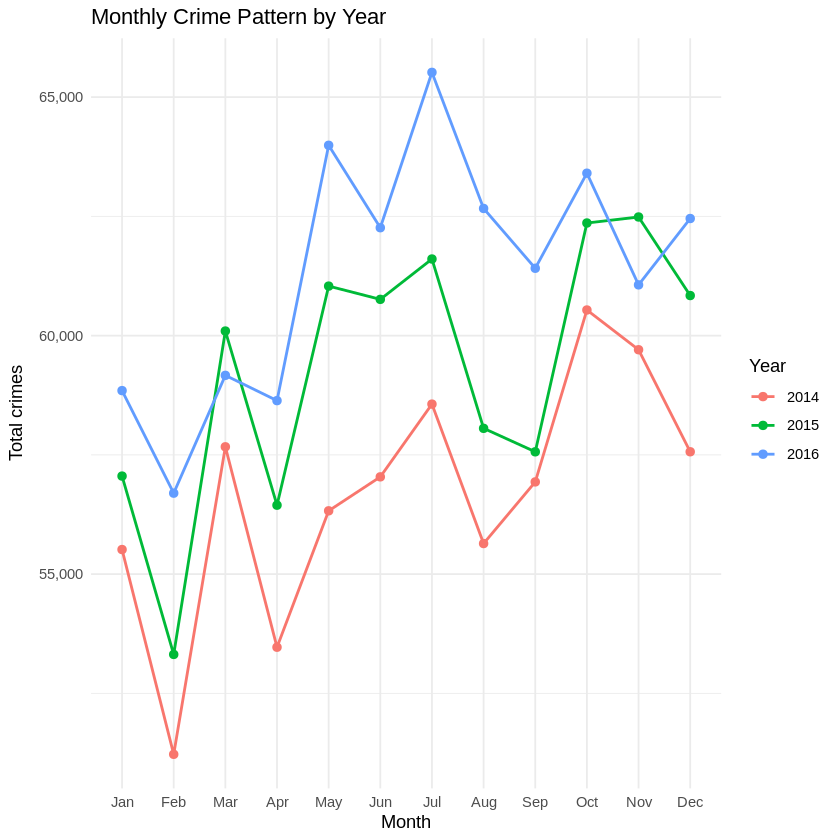

In [218]:
# Display Chart
ggplot(monthly_data, aes(x = month_factor, y = total_crime,
                         group = factor(year), colour = factor(year))) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2) +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Monthly Crime Pattern by Year",
    x = "Month",
    y = "Total crimes",
    colour = "Year"
  ) +
  theme_minimal()

### 6.3 Crime Type Vs Timeline


Total crimes by major category:
# A tibble: 7 × 2
  major_category               total
  <chr>                        <dbl>
1 Theft and Handling          858035
2 Violence Against the Person 636470
3 Burglary                    214827
4 Criminal Damage             186326
5 Drugs                       123134
6 Robbery                      66061
7 Other Notifiable Offences    43075


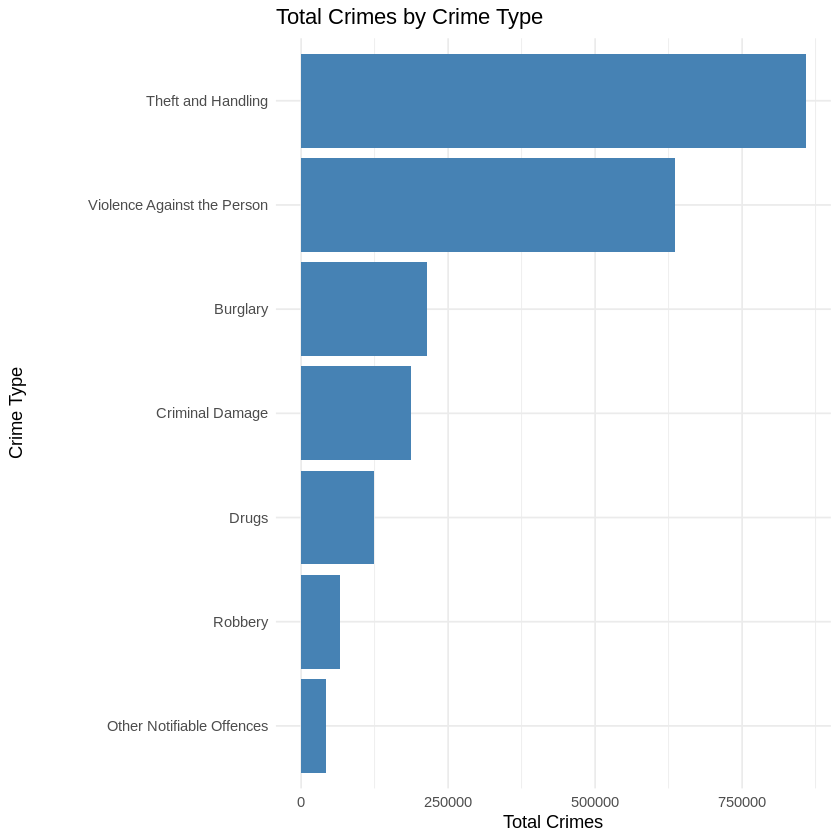

In [219]:
# Get Cal Total Crimes Per Crime Type
crime_types <- raw_data %>%
  group_by(major_category) %>%
  summarise(total = sum(total_crimes, na.rm = TRUE)) %>%
  arrange(desc(total))

# Display Values
cat("\nTotal crimes by major category:\n")
print(crime_types)

# Display Chart
ggplot(crime_types, aes(x = reorder(major_category, total), y = total)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Total Crimes by Crime Type",
    x = "Crime Type",
    y = "Total Crimes"
  ) +
  theme_minimal()

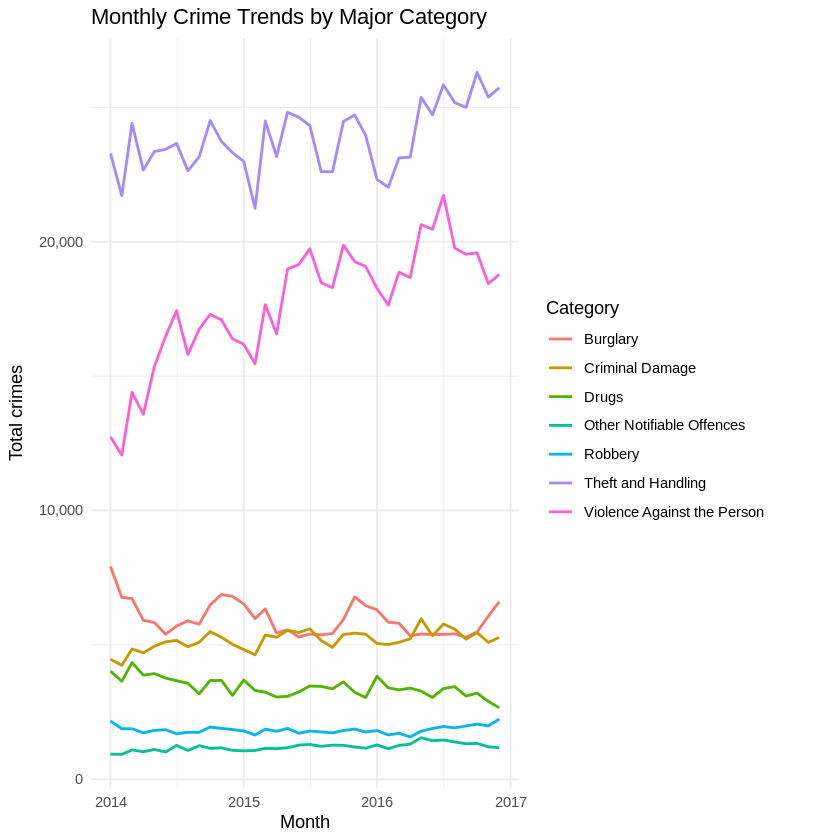

In [220]:
# Display Chart
ggplot(category_monthly, aes(x = crime_month, y = total_crimes, colour = major_category, group = major_category)) +
  geom_line(linewidth = 0.8) +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Monthly Crime Trends by Major Category",
    x = "Month",
    y = "Total crimes",
    colour = "Category"
  ) +
  theme_minimal()

## 7. Save Models
Export the processed datasets so that they can be reused in the regression and TensorFlow notebooks for predictive modelling.

In [221]:
write_csv(category_monthly, "category_monthly.csv")
write_csv(monthly_data, "monthly_totals.csv")